# 🌳 Árbol de Regresión — Predicción de Salario
**Dataset:** Tech Salary Dataset (250,000 muestras | 10 variables)  
**Variable objetivo:** `salario` (valor numérico continuo en USD)  
**Estructura:** Igual al notebook de Estrés, adaptado a datos de salarios en tecnología

## 📦 1. Librerías

In [ ]:
# ── Librerías ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,    # MAE  → error promedio en las mismas unidades
    mean_squared_error,     # MSE  → penaliza más los errores grandes
    r2_score                # R²   → qué % de la varianza explica el modelo
)

## 📂 2. Cargar y explorar el dataset

In [ ]:
# ── Cargar dataset ────────────────────────────────────────────────────────────
# Tech Salary Dataset: predice el salario anual (en USD)
# 250,000 muestras | 10 variables (título, experiencia, educación, industria, etc.)
datos = pd.read_excel('datossalarios.xlsx')

print('Forma del dataset:', datos.shape)
print('\nColumnas:', list(datos.columns))
datos

Forma del dataset: (250000, 10)

Columnas: ['titulo_profesional', 'anios_experiencia', 'nivel_educativo', 'numero_habilidades', 'industria', 'tamaño_empresa', 'ubicación', 'trabajo_remoto', 'certificaciones', 'salario']


,titulo_profesional,anios_experiencia,nivel_educativo,numero_habilidades,industria,tamaño_empresa,ubicación,trabajo_remoto,certificaciones,salario
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


## 🔧 3. Preprocesamiento — Codificar variables categóricas

In [ ]:
# ── Codificar variables categóricas ──────────────────────────────────────────
# titulo_profesional: AI Engineer / Data Analyst / ... → 0, 1, 2 ...
datos['titulo_encoded'] = datos['titulo_profesional'].astype('category').cat.codes

# nivel_educativo: High School / Diploma / Bachelor / Master / PhD → 0..4
datos['educacion_encoded'] = datos['nivel_educativo'].astype('category').cat.codes

# industria: Education / Finance / Healthcare / ... → 0..9
datos['industria_encoded'] = datos['industria'].astype('category').cat.codes

# tamaño_empresa: Small / Medium / Large / Enterprise / Startup → 0..4
datos['tamaño_encoded'] = datos['tamaño_empresa'].astype('category').cat.codes

# ubicación: Australia / Canada / India / ... → 0..9
datos['ubicacion_encoded'] = datos['ubicación'].astype('category').cat.codes

# trabajo_remoto: Hybrid / No / Yes → 0 / 1 / 2
datos['remoto_encoded'] = datos['trabajo_remoto'].astype('category').cat.codes

# ── Mostrar el mapeo para entender los códigos ────────────────────────────────
print('titulo_profesional:', dict(enumerate(datos['titulo_profesional'].astype('category').cat.categories)))
print('nivel_educativo    :', dict(enumerate(datos['nivel_educativo'].astype('category').cat.categories)))
print('industria          :', dict(enumerate(datos['industria'].astype('category').cat.categories)))
print('tamaño_empresa     :', dict(enumerate(datos['tamaño_empresa'].astype('category').cat.categories)))
print('ubicación          :', dict(enumerate(datos['ubicación'].astype('category').cat.categories)))
print('trabajo_remoto     :', dict(enumerate(datos['trabajo_remoto'].astype('category').cat.categories)))

titulo_profesional: {0: 'AI Engineer', 1: 'Backend Developer', 2: 'Business Analyst', 3: 'Cloud Engineer', 4: 'Cybersecurity Analyst', 5: 'Data Analyst', 6: 'Data Scientist', 7: 'DevOps Engineer', 8: 'Frontend Developer', 9: 'Machine Learning Engineer', 10: 'Product Manager', 11: 'Software Engineer'}
nivel_educativo    : {0: 'Bachelor', 1: 'Diploma', 2: 'High School', 3: 'Master', 4: 'PhD'}
industria          : {0: 'Consulting', 1: 'Education', 2: 'Finance', 3: 'Government', 4: 'Healthcare', 5: 'Manufacturing', 6: 'Media', 7: 'Retail', 8: 'Technology', 9: 'Telecom'}
tamaño_empresa     : {0: 'Enterprise', 1: 'Large', 2: 'Medium', 3: 'Small', 4: 'Startup'}
ubicación          : {0: 'Australia', 1: 'Canada', 2: 'Germany', 3: 'India', 4: 'Netherlands', 5: 'Remote', 6: 'Singapore', 7: 'Sweden', 8: 'UK', 9: 'USA'}
trabajo_remoto     : {0: 'Hybrid', 1: 'No', 2: 'Yes'}


## 🎯 4. Definir X (características) e y (variable objetivo)

In [ ]:
# ── Seleccionar features y target ────────────────────────────────────────────
# Eliminamos las columnas originales categóricas y usamos las codificadas
columnas_excluir = [
    'titulo_profesional', 'nivel_educativo', 'industria',
    'tamaño_empresa', 'ubicación', 'trabajo_remoto',
    'salario'
]

X = datos.drop(columns=columnas_excluir)
y = datos['salario'].rename('SalarioUSD')   # Variable CUANTITATIVA

print('Forma de X:', X.shape)
print('Rango de y: $', y.min(), '→ $', y.max())
print('\nFeatures usadas:', list(X.columns))
print('\nPrimeras filas:')
print(X.head(3))
print(y.head(3))

Forma de X: (250000, 9)
Rango de y: $ 31867 → $ 333046

Features usadas: ['anios_experiencia', 'numero_habilidades', 'certificaciones', 'titulo_encoded', 'educacion_encoded', 'industria_encoded', 'tamaño_encoded', 'ubicacion_encoded', 'remoto_encoded']

Primeras filas:
   anios_experiencia  numero_habilidades  certificaciones  titulo_encoded  \
0                 10                   2                2               0   
1                  5                  17                0               5   
2                 18                   4                1               8   

   educacion_encoded  industria_encoded  tamaño_encoded  ubicacion_encoded  \
0                  0                  4               2                  3   
1                  0                  9               3                  0   
2                  4                  6               2                  6   

   remoto_encoded  
0               0  
1               1  
2               1  
0    109413
1     93764
2   

## ✂️ 5. División 80% entrenamiento / 20% prueba

In [ ]:
# ── Split 80% / 20% ───────────────────────────────────────────────────────────
# En regresión NO se usa stratify (es para clasificación)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Entrenamiento:', X_train.shape)   # ~200,000 muestras
print('Prueba:       ', X_test.shape)    # ~50,000 muestras

Entrenamiento: (200000, 9)
Prueba:        (50000, 9)


## 🌳 6. Entrenar el Árbol de Regresión

In [ ]:
# ── DecisionTreeRegressor (NO Classifier) ────────────────────────────────────
# criterion='squared_error' → minimiza el MSE en cada división
# max_depth=5               → controla la complejidad; más profundo = más sobreajuste
# min_samples_split=20      → un nodo necesita al menos 20 muestras para dividirse
# min_samples_leaf=10       → cada hoja debe tener al menos 10 muestras
# random_state=42           → reproducibilidad

arbol_reg = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# ── Entrenar ──────────────────────────────────────────────────────────────────
arbol_reg.fit(X_train, y_train)

print('Profundidad real:', arbol_reg.get_depth())
print('Número de hojas: ', arbol_reg.get_n_leaves())

Profundidad real: 5
Número de hojas:  32


## 🔮 7. Predicciones

In [ ]:
# ── Predecir valores numéricos continuos ─────────────────────────────────────
# predict() devuelve el PROMEDIO de y_train de las muestras en cada hoja
y_pred = arbol_reg.predict(X_test)

In [ ]:
# ── Ver comparación real vs predicho ─────────────────────────────────────────
comparacion = pd.DataFrame({
    'Real'    : y_test.values[:10],
    'Predicho': y_pred[:10].round(2),
    'Error'   : (y_test.values[:10] - y_pred[:10]).round(2)
})

print('\nComparación Real vs Predicho (primeras 10 muestras):')
print(comparacion.to_string(index=False))


Comparación Real vs Predicho (primeras 10 muestras):
  Real  Predicho     Error
164009 147428.12  16580.88
 79594 120471.99 -40877.99
 74090 102758.16 -28668.16
177193 119740.43  57452.57
120012 123898.49  -3886.49
163369 144673.44  18695.56
111889 120471.99  -8582.99
 75418 102758.16 -27340.16
103067 141681.25 -38614.25
190692 168315.07  22376.93


## 📊 8. Métricas de regresión

In [ ]:
# ── Métricas de regresión ─────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('=' * 50)
print('        MÉTRICAS DE REGRESIÓN')
print('=' * 50)
print(f'  MAE  (Error Absoluto Medio)  : ${mae:,.2f} USD')
print(f'  MSE  (Error Cuadrático Medio): {mse:,.2f}')
print(f'  RMSE (Raíz del MSE)          : ${rmse:,.2f} USD')
print(f'  R²   (Coef. Determinación)   : {r2:.4f}  →  {r2*100:.2f}%')
print('=' * 50)

# ── Interpretación rápida ─────────────────────────────────────────────────────
# MAE  → en promedio el modelo se equivoca en $MAE USD
# RMSE → igual que MAE pero penaliza errores grandes
# R²   → el modelo explica el X% de la variabilidad del salario

        MÉTRICAS DE REGRESIÓN
  MAE  (Error Absoluto Medio)  : $18,827.96 USD
  MSE  (Error Cuadrático Medio): 551,610,495.13
  RMSE (Raíz del MSE)          : $23,486.39 USD
  R²   (Coef. Determinación)   : 0.6031  →  60.31%


## 📈 9. Gráfica: Predicciones vs Años de Experiencia

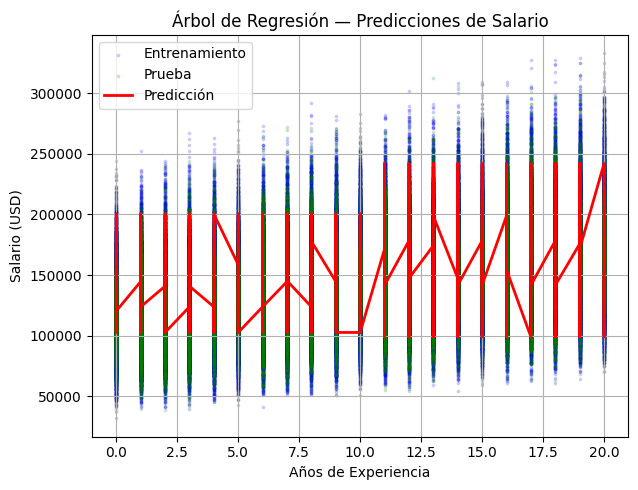

In [ ]:
# ── Ordenar por anios_experiencia para línea de predicción suave ─────────────
plt.figure(figsize=(12, 5))

combined_test = pd.DataFrame({
    'anios_experiencia': X_test['anios_experiencia'],
    'y_test'           : y_test,
    'y_pred'           : y_pred
})
combined_sorted = combined_test.sort_values(by='anios_experiencia')

plt.subplot(1, 2, 1)
plt.scatter(X_train['anios_experiencia'], y_train,
            color='blue', alpha=0.15, s=3, label='Entrenamiento')
plt.scatter(X_test['anios_experiencia'], y_test,
            color='green', alpha=0.15, s=3, label='Prueba')
plt.plot(combined_sorted['anios_experiencia'], combined_sorted['y_pred'],
         color='red', linewidth=2, label='Predicción')
plt.xlabel('Años de Experiencia')
plt.ylabel('Salario (USD)')
plt.title('Árbol de Regresión — Predicciones de Salario')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 📉 10. Evaluación visual: Real vs Predicho y Residuos

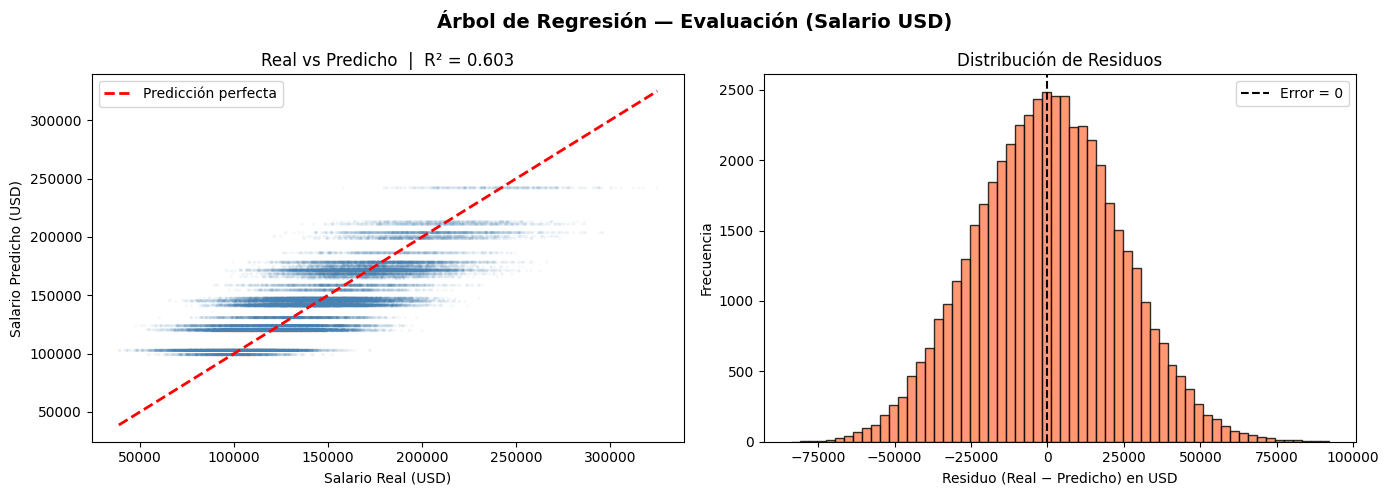

In [ ]:
# ── Scatter: si el modelo fuera perfecto, todos los puntos
#    estarían sobre la línea diagonal roja ──────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Gráfico 1: Real vs Predicho ───────────────────────────────────────────────
axes[0].scatter(y_test, y_pred, alpha=0.05, color='steelblue',
                edgecolors='none', s=5)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Predicción perfecta'
)
axes[0].set_xlabel('Salario Real (USD)')
axes[0].set_ylabel('Salario Predicho (USD)')
axes[0].set_title(f'Real vs Predicho  |  R² = {r2:.3f}')
axes[0].legend()

# ── Gráfico 2: Distribución de residuos ──────────────────────────────────────
# Residuo = Real - Predicho
# Un buen modelo tiene residuos centrados en 0 y distribuidos simétricamente
residuos = y_test.values - y_pred

axes[1].hist(residuos, bins=60, color='coral', edgecolor='black', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Error = 0')
axes[1].set_xlabel('Residuo (Real − Predicho) en USD')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].legend()

plt.suptitle('Árbol de Regresión — Evaluación (Salario USD)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🌲 11. Visualización gráfica del árbol

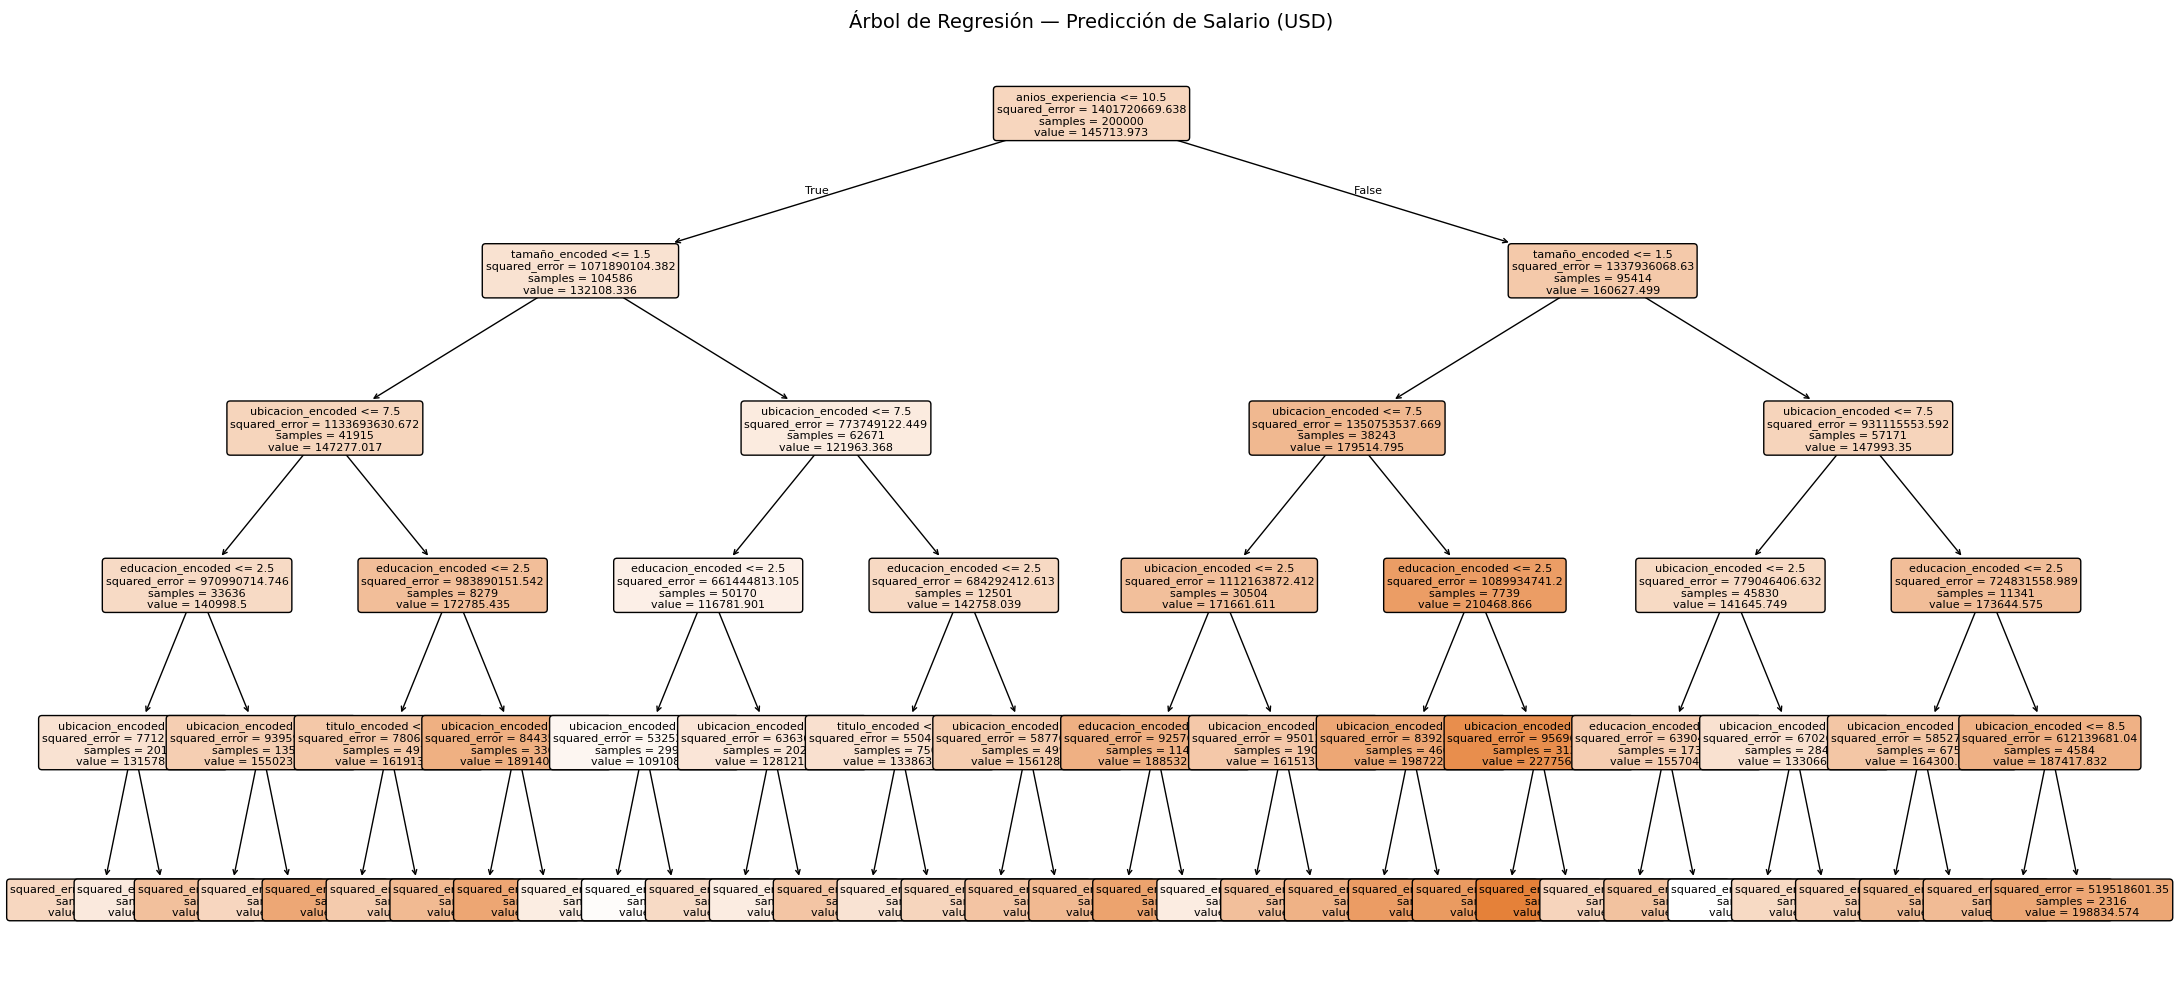


Reglas del árbol (primeras 60 líneas):
|--- anios_experiencia <= 10.50
|   |--- tamaño_encoded <= 1.50
|   |   |--- ubicacion_encoded <= 7.50
|   |   |   |--- educacion_encoded <= 2.50
|   |   |   |   |--- ubicacion_encoded <= 2.50
|   |   |   |   |   |--- value: [144673.44]
|   |   |   |   |--- ubicacion_encoded >  2.50
|   |   |   |   |   |--- value: [123898.49]
|   |   |   |--- educacion_encoded >  2.50
|   |   |   |   |--- ubicacion_encoded <= 2.50
|   |   |   |   |   |--- value: [170966.56]
|   |   |   |   |--- ubicacion_encoded >  2.50
|   |   |   |   |   |--- value: [145409.31]
|   |   |--- ubicacion_encoded >  7.50
|   |   |   |--- educacion_encoded <= 2.50
|   |   |   |   |--- titulo_encoded <= 0.50
|   |   |   |   |   |--- value: [198716.74]
|   |   |   |   |--- titulo_encoded >  0.50
|   |   |   |   |   |--- value: [158570.93]
|   |   |   |--- educacion_encoded >  2.50
|   |   |   |   |--- ubicacion_encoded <= 8.50
|   |   |   |   |   |--- value: [177912.12]
|   |   |   |  

In [ ]:
# ── Visualización gráfica ─────────────────────────────────────────────────────
# En cada nodo se muestra:
#   - La condición de división (ej: anios_experiencia <= 7.5)
#   - squared_error → MSE del nodo
#   - samples       → cuántas muestras cayeron aquí
#   - value         → PROMEDIO del salario en ese nodo (la predicción)

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    arbol_reg,
    feature_names=X.columns,
    filled=True,      # Color más intenso = salario más alto
    rounded=True,
    fontsize=8,
    ax=ax,
    precision=3
)
ax.set_title('Árbol de Regresión — Predicción de Salario (USD)',
             fontsize=14)
plt.tight_layout()
plt.show()

# ── Versión texto ─────────────────────────────────────────────────────────────
reglas = export_text(arbol_reg, feature_names=list(X.columns))
print('\nReglas del árbol (primeras 60 líneas):')
print('\n'.join(reglas.split('\n')[:60]))

## 🏆 12. Importancia de características


Importancia de características:
    Característica  Importancia
 ubicacion_encoded     0.415983
 anios_experiencia     0.239100
    tamaño_encoded     0.228971
 educacion_encoded     0.108306
    titulo_encoded     0.007640
numero_habilidades     0.000000
   certificaciones     0.000000
 industria_encoded     0.000000
    remoto_encoded     0.000000


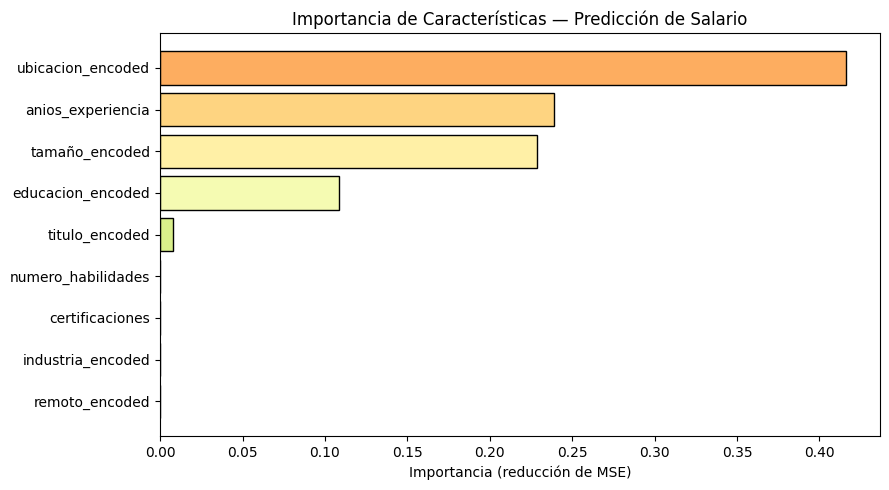

In [ ]:
# ── Qué variables influyen más en predecir el salario ─────────────────────────
importancias = arbol_reg.feature_importances_

df_imp = pd.DataFrame({
    'Característica': X.columns,
    'Importancia'   : importancias
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print('\nImportancia de características:')
print(df_imp.to_string(index=False))

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colores = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_imp)))
ax.barh(df_imp['Característica'], df_imp['Importancia'],
        color=colores, edgecolor='black')
ax.set_xlabel('Importancia (reducción de MSE)')
ax.set_title('Importancia de Características — Predicción de Salario')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 💼 13. Predecir el salario de un profesional nuevo

In [ ]:
# ── Predecir el salario de un profesional con características específicas ───────
# Ver los mapeos del Paso 3 para los códigos correctos
# Ejemplo: Data Analyst, 5 años exp, Bachelor, 10 habilidades,
#          Finance, Large, USA, No remoto, 1 certificación

nueva_muestra = pd.DataFrame([{
    'anios_experiencia'  : 5,
    'numero_habilidades' : 10,
    'certificaciones'    : 1,
    'titulo_encoded'     : 1,    # ver mapeo → Data Analyst
    'educacion_encoded'  : 1,    # ver mapeo → Bachelor
    'industria_encoded'  : 2,    # ver mapeo → Finance
    'tamaño_encoded'     : 2,    # ver mapeo → Large
    'ubicacion_encoded'  : 6,    # ver mapeo → USA
    'remoto_encoded'     : 1,    # ver mapeo → No
}])

salario_predicho = arbol_reg.predict(nueva_muestra)

print('\nCaracterísticas del profesional:')
for col, val in zip(nueva_muestra.columns, nueva_muestra.values[0]):
    print(f'  {col:25s}: {val}')

print(f'\n💰 Salario predicho: ${salario_predicho[0]:,.2f} USD/año')


Características del profesional:
  anios_experiencia        : 5
  numero_habilidades       : 10
  certificaciones          : 1
  titulo_encoded           : 1
  educacion_encoded        : 1
  industria_encoded        : 2
  tamaño_encoded           : 2
  ubicacion_encoded        : 6
  remoto_encoded           : 1

💰 Salario predicho: $102,758.16 USD/año


---
## ⚙️ OPTIMIZANDO EL ÁRBOL

## 🔍 14. Librerías de optimización

In [ ]:
# ── Librerías adicionales para optimización ───────────────────────────────────
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    validation_curve,
    learning_curve
)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (200000, 9) | Test: (50000, 9)


## 📉 15. Árbol base (sin optimizar)

In [ ]:
# ── Árbol sin ningún control de hiperparámetros ───────────────────────────────
# Esto nos da el "peor caso" para comparar después de optimizar

arbol_base = DecisionTreeRegressor(random_state=42)
arbol_base.fit(X_train, y_train)
y_pred_base = arbol_base.predict(X_test)

r2_base   = r2_score(y_test, y_pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)

print('=' * 45)
print('  ÁRBOL BASE (sin optimizar)')
print('=' * 45)
print(f'  R²   : {r2_base:.4f}')
print(f'  RMSE : ${rmse_base:,.2f} USD')
print(f'  MAE  : ${mae_base:,.2f} USD')
print(f'  Profundidad: {arbol_base.get_depth()}')
print(f'  Hojas      : {arbol_base.get_n_leaves()}')

  ÁRBOL BASE (sin optimizar)
  R²   : 0.9312
  RMSE : $9,781.38 USD
  MAE  : $7,595.35 USD
  Profundidad: 31
  Hojas      : 199895


## 🔄 16. Validación cruzada (cross_val_score)

In [ ]:
# ── cross_val_score evalúa el modelo con K particiones del train ──────────────
# cv=5   → divide X_train en 5 partes; entrena en 4 y valida en 1, rotando
# El resultado es el R² promedio de los 5 folds → estimación honesta

arbol_cv = DecisionTreeRegressor(max_depth=5, random_state=42)

scores_r2 = cross_val_score(
    arbol_cv, X_train, y_train,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

scores_rmse = cross_val_score(
    arbol_cv, X_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print('\nValidación Cruzada (5 folds) — max_depth=5:')
print(f'  R²   por fold : {scores_r2.round(4)}')
print(f'  R²   promedio : {scores_r2.mean():.4f} ± {scores_r2.std():.4f}')
print(f'  RMSE promedio : ${(-scores_rmse).mean():,.2f} ± ${scores_rmse.std():,.2f} USD')


Validación Cruzada (5 folds) — max_depth=5:
  R²   por fold : [0.6011 0.6096 0.6107 0.6    0.6074]
  R²   promedio : 0.6057 ± 0.0044
  RMSE promedio : $23,507.64 ± $126.57 USD


## 📊 17. Curva de validación — max_depth

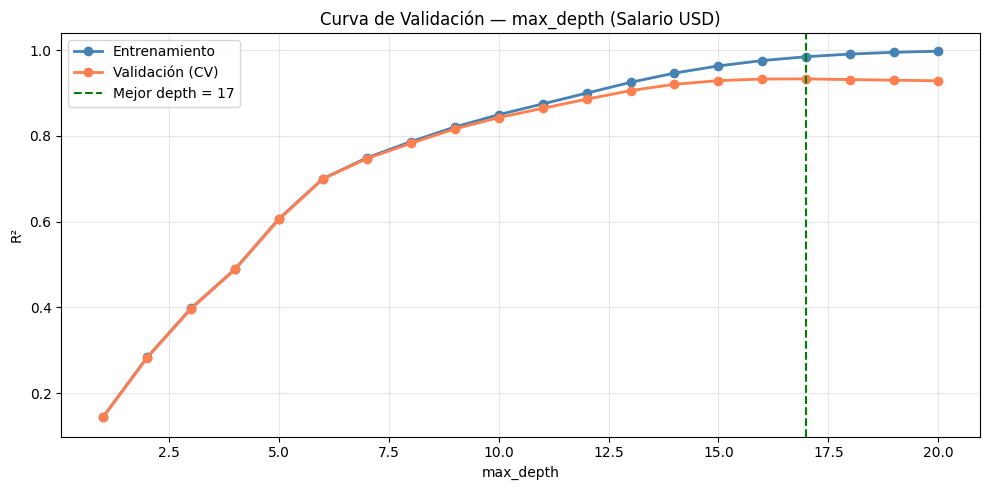


Mejor max_depth según curva de validación: 17
R² validación en ese punto: 0.9328


In [ ]:
# ── Curva de validación para max_depth ────────────────────────────────────────
profundidades = np.arange(1, 21)   # Probar profundidades del 1 al 20

train_scores, val_scores = validation_curve(
    DecisionTreeRegressor(random_state=42),
    X_train, y_train,
    param_name='max_depth',
    param_range=profundidades,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(profundidades, train_mean, 'o-', color='steelblue',
        label='Entrenamiento', linewidth=2)
ax.fill_between(profundidades,
                train_mean - train_std,
                train_mean + train_std, alpha=0.15, color='steelblue')

ax.plot(profundidades, val_mean, 'o-', color='coral',
        label='Validación (CV)', linewidth=2)
ax.fill_between(profundidades,
                val_mean - val_std,
                val_mean + val_std, alpha=0.15, color='coral')

mejor_depth = profundidades[np.argmax(val_mean)]
ax.axvline(mejor_depth, color='green', linestyle='--', linewidth=1.5,
           label=f'Mejor depth = {mejor_depth}')

ax.set_xlabel('max_depth')
ax.set_ylabel('R²')
ax.set_title('Curva de Validación — max_depth (Salario USD)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nMejor max_depth según curva de validación: {mejor_depth}')
print(f'R² validación en ese punto: {val_mean[mejor_depth-1]:.4f}')

## 🔬 18. GridSearchCV — búsqueda exhaustiva de hiperparámetros

In [ ]:
# ── Definir la grid de hiperparámetros a explorar ────────────────────────────
# GridSearch prueba TODAS las combinaciones: 5×3×3×3 = 135 combinaciones
# Con cv=5 → entrena 135 × 5 = 675 veces en total
# ⚠️ Con 250,000 filas puede tardar unos minutos

param_grid = {
    'max_depth'        : [3, 5, 7, 10, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'max_features'     : ['sqrt', 'log2', None]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(criterion='squared_error', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print('\nMejores hiperparámetros encontrados:')
for param, valor in grid_search.best_params_.items():
    print(f'  {param:20s}: {valor}')
print(f'\nMejor R² en validación cruzada: {grid_search.best_score_:.4f}')

# ── Evaluar el mejor árbol en el set de prueba ────────────────────────────────
mejor_arbol = grid_search.best_estimator_
y_pred_opt  = mejor_arbol.predict(X_test)

r2_opt   = r2_score(y_test, y_pred_opt)
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
mae_opt  = mean_absolute_error(y_test, y_pred_opt)

print('\n' + '=' * 50)
print('  COMPARACIÓN BASE vs OPTIMIZADO')
print('=' * 50)
print(f'  Métrica  | Base          | Optimizado')
print(f'  R²       | {r2_base:.4f}        | {r2_opt:.4f}')
print(f'  RMSE     | ${rmse_base:>10,.2f}  | ${rmse_opt:>10,.2f}')
print(f'  MAE      | ${mae_base:>10,.2f}  | ${mae_opt:>10,.2f}')
print('=' * 50)

Fitting 5 folds for each of 135 candidates, totalling 675 fits

Mejores hiperparámetros encontrados:
  max_depth           : None
  max_features        : None
  min_samples_leaf    : 5
  min_samples_split   : 10

Mejor R² en validación cruzada: 0.9406

  COMPARACIÓN BASE vs OPTIMIZADO
  Métrica  | Base          | Optimizado
  R²       | 0.9312        | 0.9448
  RMSE     | $  9,781.38  | $  8,758.47
  MAE      | $  7,595.35  | $  6,812.15


## 🎲 19. RandomizedSearchCV — búsqueda aleatoria de hiperparámetros

In [ ]:
# ── RandomizedSearch es ideal cuando la grilla es muy grande ─────────────────
# n_iter=80 → prueba solo 80 combinaciones aleatorias
# Útil cuando tienes muchos hiperparámetros o rangos continuos

from scipy.stats import randint, uniform

param_dist = {
    'max_depth'           : randint(2, 15),
    'min_samples_split'   : randint(5, 100),
    'min_samples_leaf'    : randint(2, 50),
    'max_features'        : [None, 'sqrt', 'log2'],
    'min_impurity_decrease': uniform(0.0, 10.0)   # más amplio por escala del salario
}

arbol_rand = DecisionTreeRegressor(
    criterion='squared_error',
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=arbol_rand,
    param_distributions=param_dist,
    n_iter=80,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1,
    random_state=42,
    return_train_score=True
)

random_search.fit(X_train, y_train)

print('\n' + '=' * 50)
print('  RESULTADOS RANDOMIZEDSEARCHCV')
print('=' * 50)
print(f'  Mejores parámetros : {random_search.best_params_}')
print(f'  Mejor RMSE (CV)    : ${-random_search.best_score_:,.2f} USD')

Fitting 5 folds for each of 80 candidates, totalling 400 fits

  RESULTADOS RANDOMIZEDSEARCHCV
  Mejores parámetros : {'max_depth': 14, 'max_features': None, 'min_impurity_decrease': np.float64(0.7697990982879299), 'min_samples_leaf': 23, 'min_samples_split': 32}
  Mejor RMSE (CV)    : $11,067.62 USD


## 📋 20. Tabla comparativa: Base vs GridSearch vs RandomizedSearch

In [ ]:
# ── Extraer el mejor estimador de cada búsqueda ───────────────────────────────
mejor_grid   = grid_search.best_estimator_
mejor_random = random_search.best_estimator_

# ── Predicciones en test ──────────────────────────────────────────────────────
y_pred_grid   = mejor_grid.predict(X_test)
y_pred_random = mejor_random.predict(X_test)

# ── Función de métricas inline ────────────────────────────────────────────────
def metricas(y_real, y_pred):
    return {
        'R²'       : round(r2_score(y_real, y_pred), 4),
        'RMSE(USD)': round(np.sqrt(mean_squared_error(y_real, y_pred)), 2),
        'MAE(USD)' : round(mean_absolute_error(y_real, y_pred), 2)
    }

m_base   = metricas(y_test, y_pred_base)
m_grid   = metricas(y_test, y_pred_grid)
m_random = metricas(y_test, y_pred_random)

# ── Tabla comparativa ─────────────────────────────────────────────────────────
df_resultados = pd.DataFrame(
    [m_base, m_grid, m_random],
    index=['Base (sin optimizar)', 'GridSearchCV', 'RandomizedSearchCV']
)

print('\n' + '=' * 60)
print('       COMPARACIÓN FINAL EN DATOS DE TEST (Salario USD)')
print('=' * 60)
print(df_resultados.to_string())
print('=' * 60)
print('↑ R² más alto = mejor  |  ↓ RMSE y MAE más bajos = mejor')


       COMPARACIÓN FINAL EN DATOS DE TEST (Salario USD)
                          R²  RMSE(USD)  MAE(USD)
Base (sin optimizar)  0.9312    9781.38   7595.35
GridSearchCV          0.9448    8758.47   6812.15
RandomizedSearchCV    0.9183   10656.24   8337.48
↑ R² más alto = mejor  |  ↓ RMSE y MAE más bajos = mejor


## 📈 21. Curva de aprendizaje — ¿mejora con más datos?

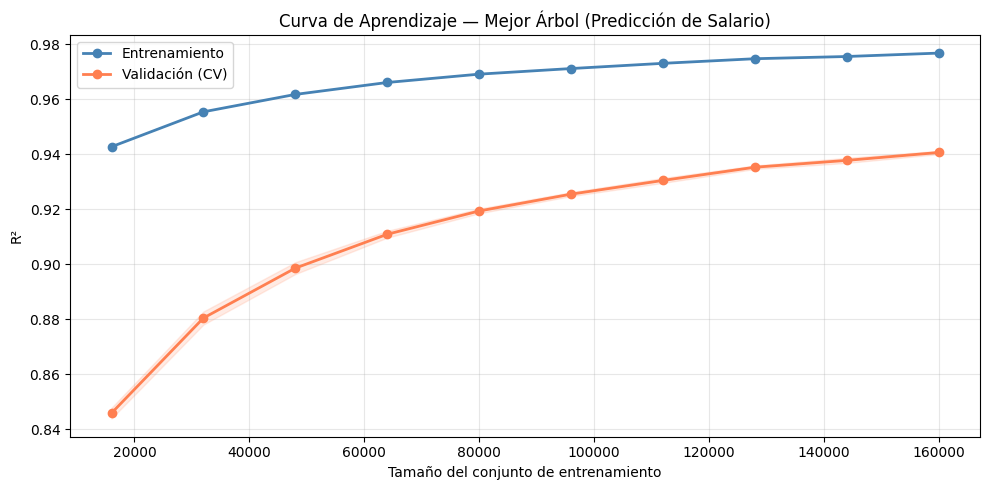

In [ ]:
# ── La curva de aprendizaje muestra si el modelo mejora con más datos ─────────
# Si train y val convergen en un valor alto → modelo bien ajustado
# Si val sigue subiendo al final → más datos ayudarían
# Si hay gran brecha entre train y val → sobreajuste

train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    mejor_grid,
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),   # del 10% al 100% del train
    cv=5,
    scoring='r2',
    n_jobs=-1
)

lc_train_mean = train_scores_lc.mean(axis=1)
lc_val_mean   = val_scores_lc.mean(axis=1)
lc_val_std    = val_scores_lc.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, lc_train_mean, 'o-', color='steelblue',
        label='Entrenamiento', linewidth=2)
ax.plot(train_sizes, lc_val_mean,   'o-', color='coral',
        label='Validación (CV)', linewidth=2)
ax.fill_between(train_sizes,
                lc_val_mean - lc_val_std,
                lc_val_mean + lc_val_std, alpha=0.15, color='coral')
ax.set_xlabel('Tamaño del conjunto de entrenamiento')
ax.set_ylabel('R²')
ax.set_title('Curva de Aprendizaje — Mejor Árbol (Predicción de Salario)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🖼️ 22. Comparación visual: Real vs Predicho (3 modelos)

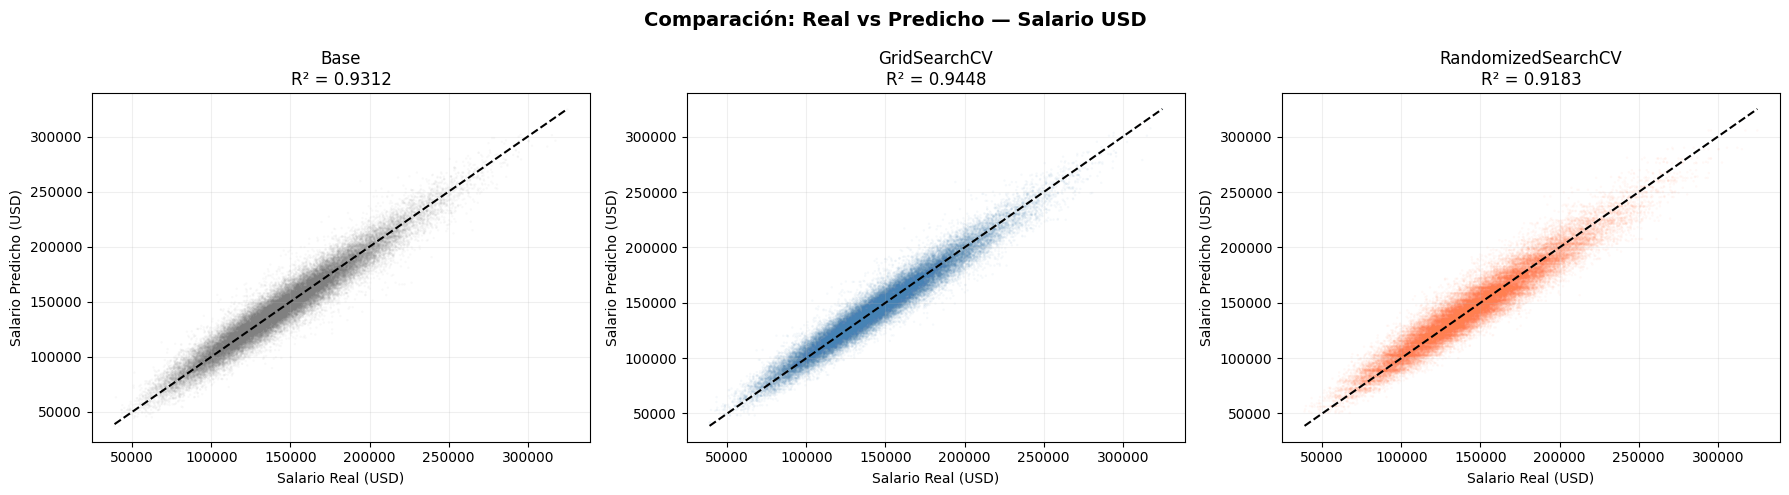

In [ ]:
# ── Real vs Predicho para los 3 modelos lado a lado ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [y_pred_base,   y_pred_grid,    y_pred_random]
titulos = ['Base',         'GridSearchCV', 'RandomizedSearchCV']
colores = ['gray',         'steelblue',    'coral']

for ax, pred, titulo, color in zip(axes, modelos, titulos, colores):
    r2 = r2_score(y_test, pred)
    ax.scatter(y_test, pred, alpha=0.05, color=color, s=3, edgecolors='none')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'k--', linewidth=1.5)
    ax.set_xlabel('Salario Real (USD)')
    ax.set_ylabel('Salario Predicho (USD)')
    ax.set_title(f'{titulo}\nR² = {r2:.4f}')
    ax.grid(True, alpha=0.2)

plt.suptitle('Comparación: Real vs Predicho — Salario USD',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🎨 23. Árbol optimizado con paleta de colores (RdYlGn)

/tmp/ipykernel_2151/851516544.py:49: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2151/851516544.py:49: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2151/851516544.py:49: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print

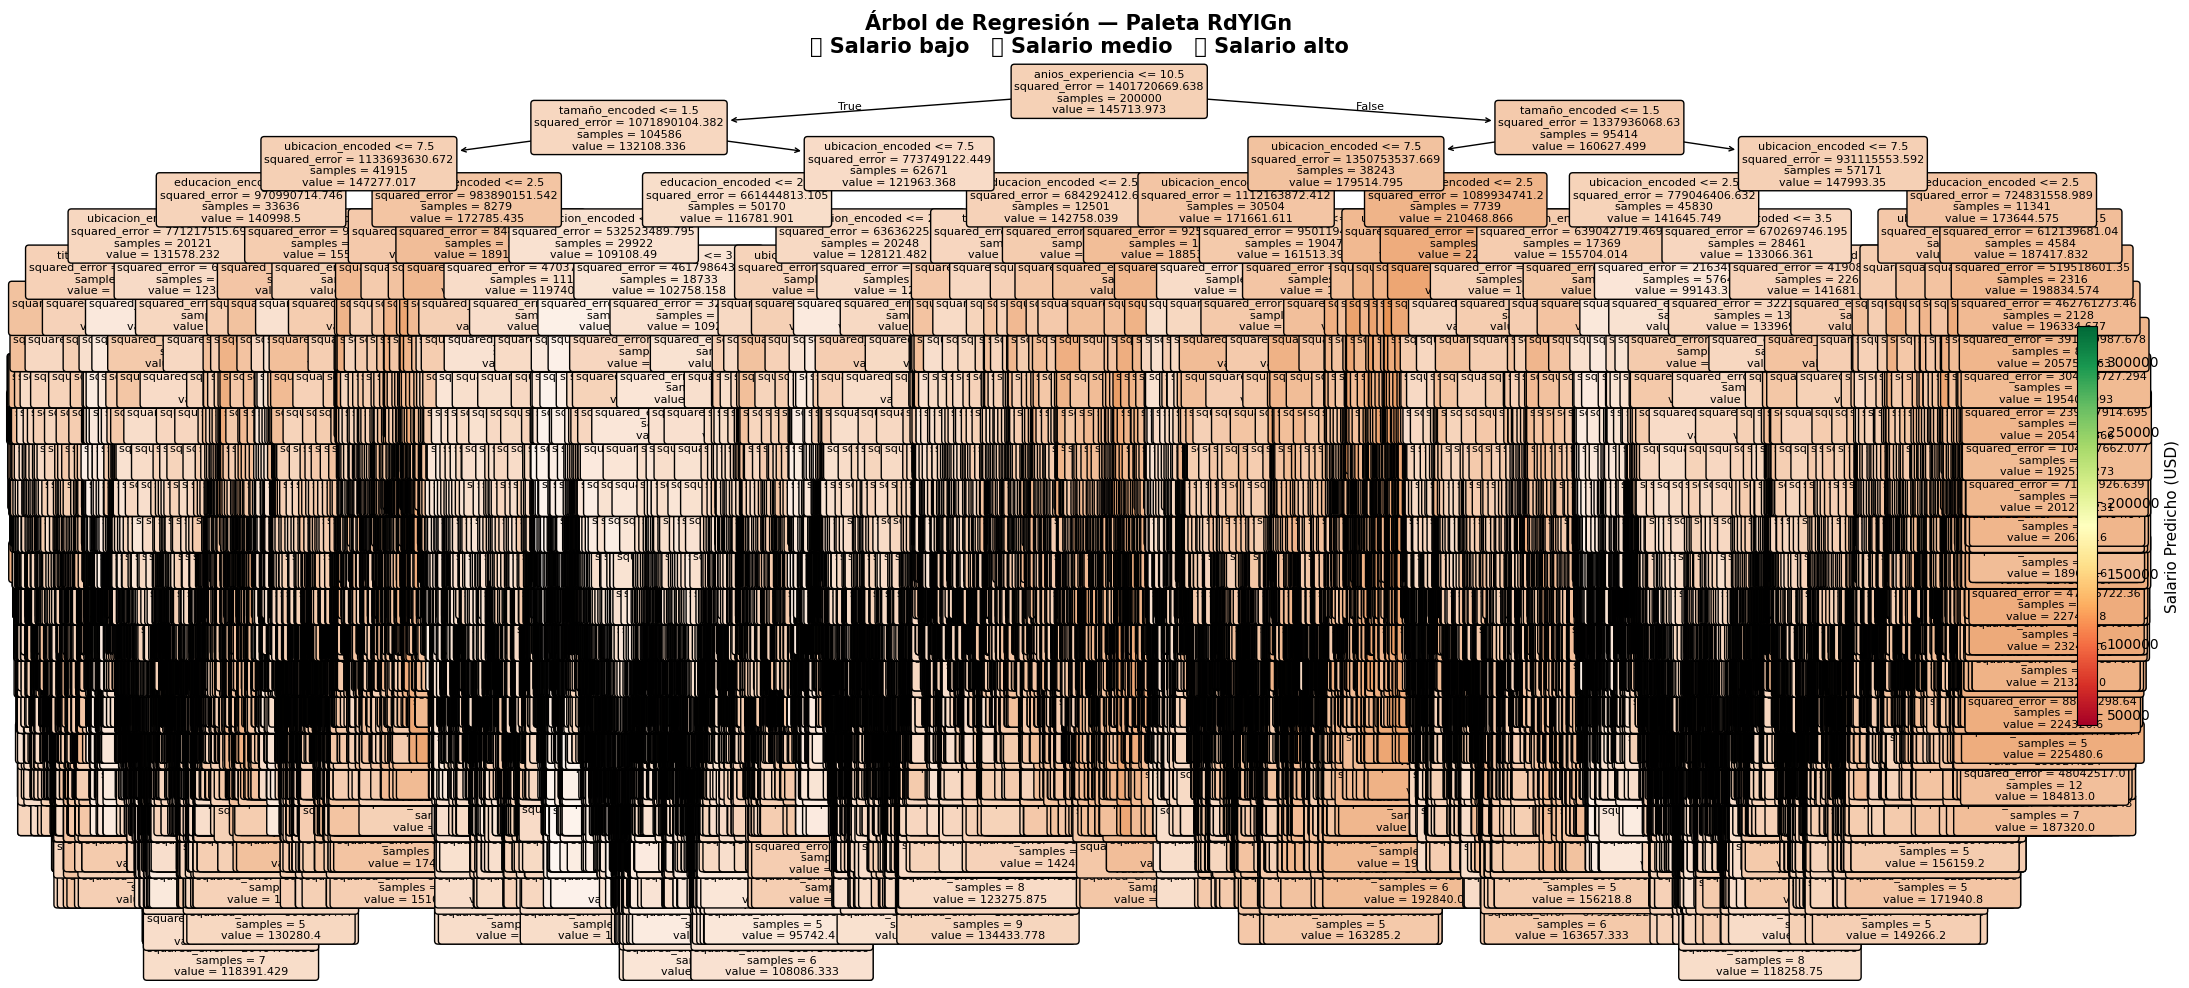

In [31]:
# ── Árbol coloreado: rojo = salario bajo, amarillo = medio, verde = alto ──────
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(figsize=(22, 10))

artistas = plot_tree(
    mejor_grid,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    precision=3
)

# ── Colorear cada nodo según el salario promedio predicho ────────────────────
tree_ = mejor_grid.tree_
valores = tree_.value[:, 0, 0]   # salario promedio de cada nodo

colormap = plt.cm.RdYlGn
norm     = Normalize(vmin=valores.min(), vmax=valores.max())
n_nodes  = tree_.node_count

nodo_idx = 0
for artist in artistas:
    if hasattr(artist, 'get_facecolor'):
        color = colormap(norm(valores[nodo_idx]))
        artist.set_facecolor(color)
        artist.set_edgecolor('black')
        artist.set_linewidth(0.8)
        nodo_idx += 1
        if nodo_idx >= n_nodes:
            break

# ── Barra de color como leyenda ───────────────────────────────────────────────
sm = ScalarMappable(cmap=colormap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='vertical',
                    fraction=0.01, pad=0.01, shrink=0.6)
cbar.set_label('Salario Predicho (USD)', fontsize=11)

ax.set_title(
    'Árbol de Regresión — Paleta RdYlGn\n'
    '🔴 Salario bajo   🟡 Salario medio   🟢 Salario alto',
    fontsize=15, fontweight='bold', pad=15
)
plt.tight_layout()
plt.show()

## 🌲 24. Árbol simplificado (3 niveles) — alta legibilidad

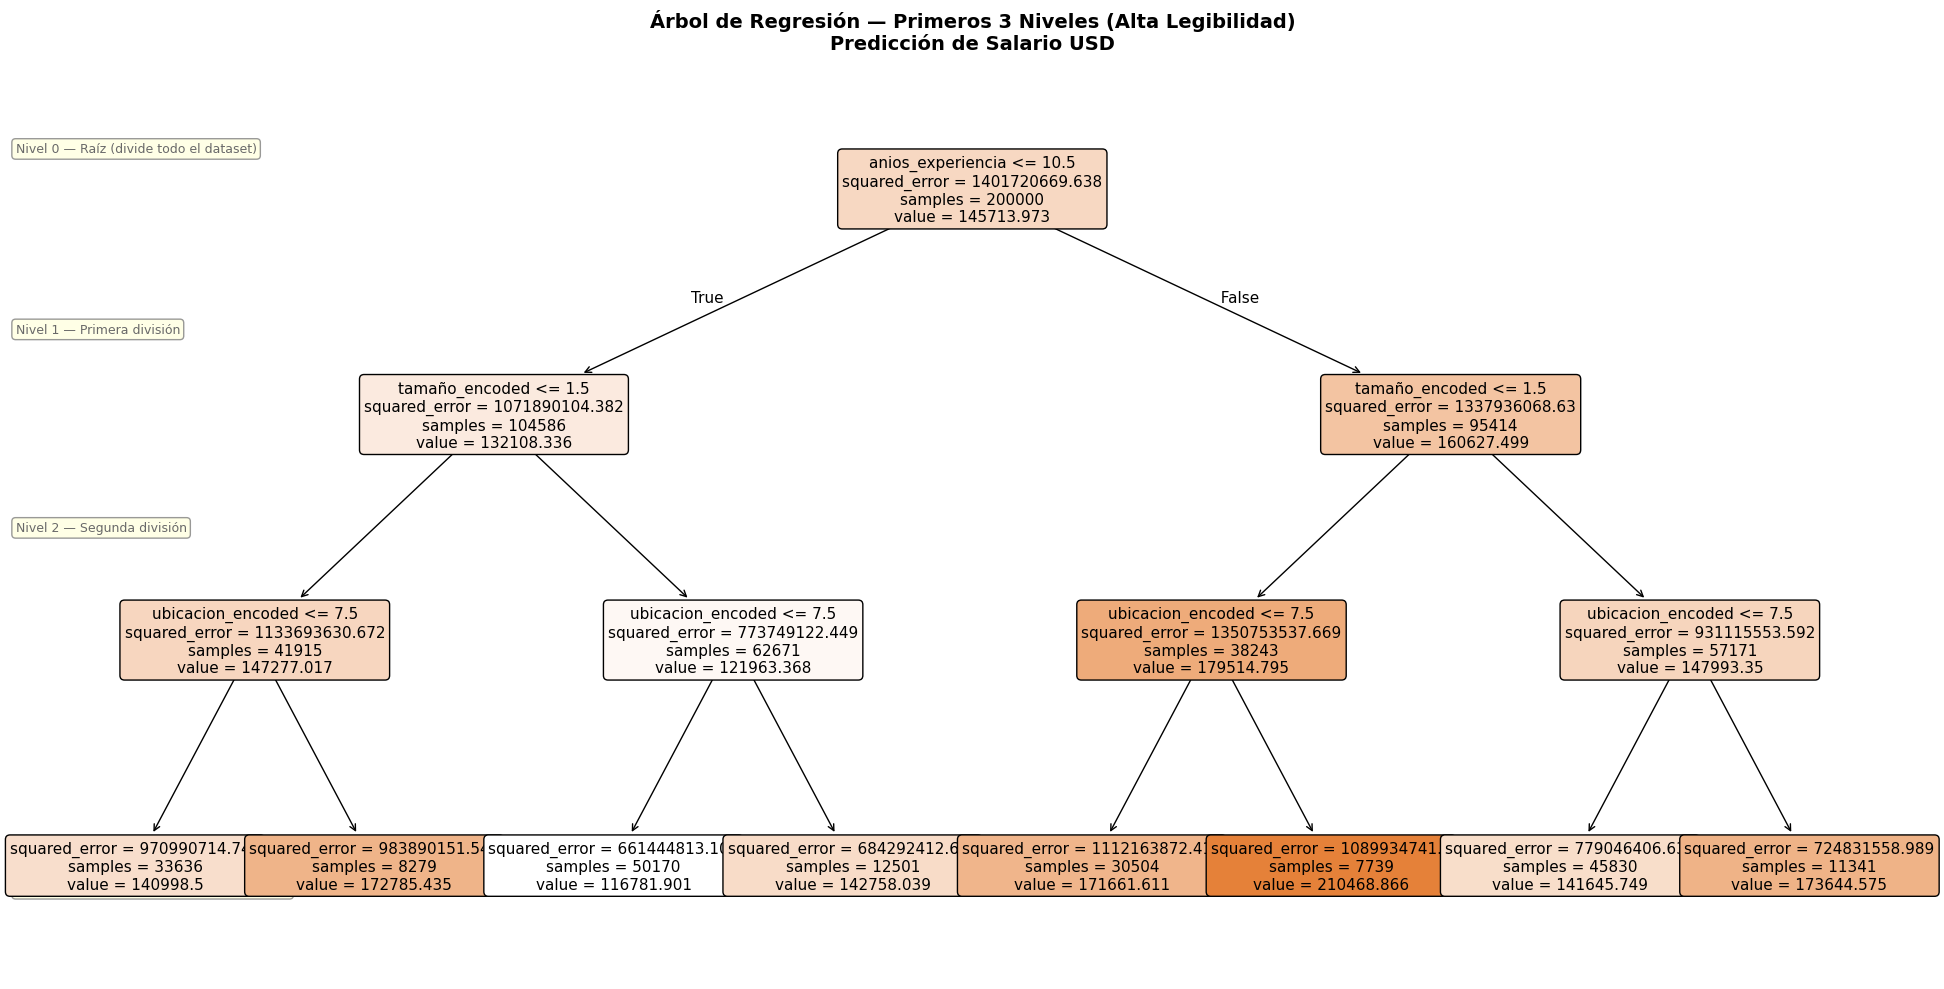

In [32]:
# ── Árbol simplificado solo para visualización (max_depth=3) ─────────────────
arbol_visual = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
arbol_visual.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    arbol_visual,
    feature_names=list(X.columns),
    filled=True,
    rounded=True,
    fontsize=11,
    precision=3,
    ax=ax,
    impurity=True,
    proportion=False
)

# ── Anotar cada nivel del árbol ───────────────────────────────────────────────
niveles = {
    0.92: 'Nivel 0 — Raíz (divide todo el dataset)',
    0.72: 'Nivel 1 — Primera división',
    0.50: 'Nivel 2 — Segunda división',
    0.10: 'Nivel 3 — Hojas (predicción final de salario)'
}

for y_pos, texto in niveles.items():
    ax.annotate(
        texto,
        xy=(0, y_pos), xycoords='axes fraction',
        fontsize=9, color='dimgray',
        ha='left', va='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.8)
    )

ax.set_title(
    'Árbol de Regresión — Primeros 3 Niveles (Alta Legibilidad)\nPredicción de Salario USD',
    fontsize=14, fontweight='bold', pad=20
)
plt.tight_layout()
plt.show()

## 🥧 25. Importancia de características con gráfico de torta

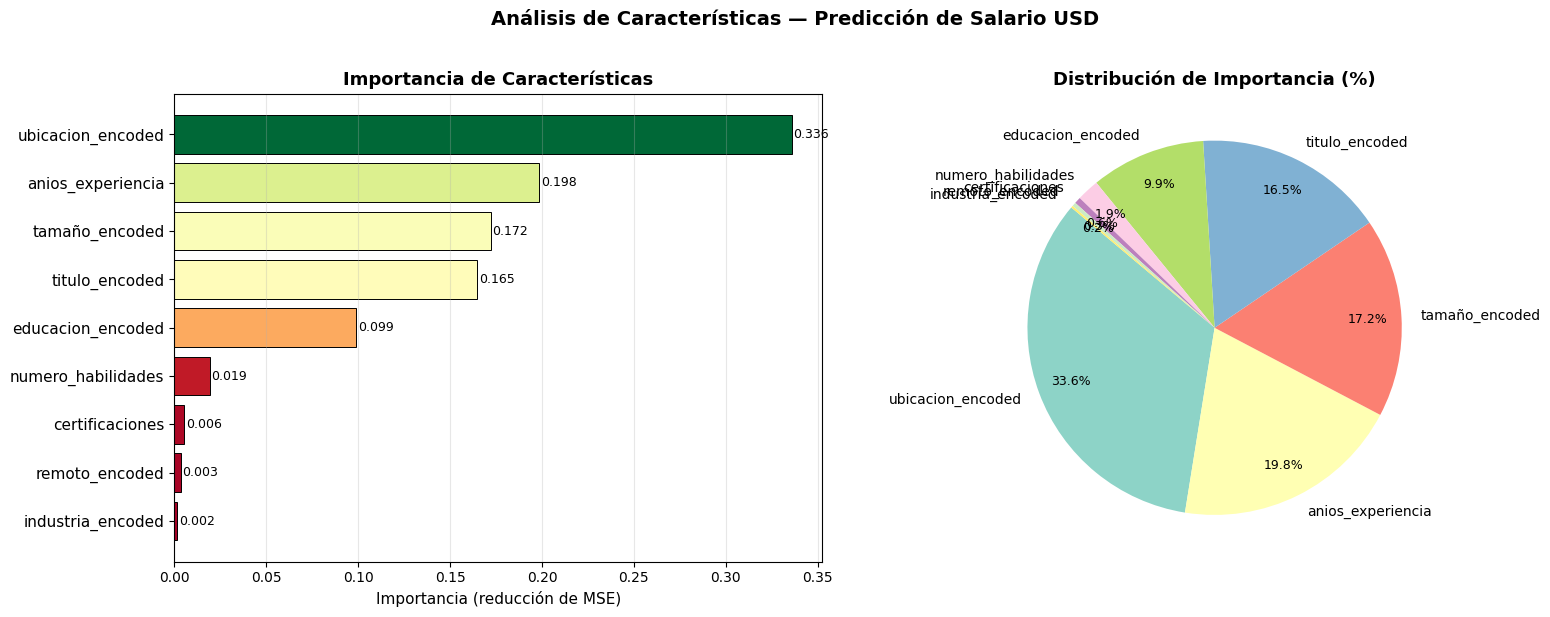

In [33]:
# ── Importancia con barras horizontales + gráfico de torta ──────────────────
importancias = mejor_grid.feature_importances_
indices      = np.argsort(importancias)[::-1]
nombres      = np.array(X.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Barras horizontales ───────────────────────────────────────────────────────
colores_imp = plt.cm.RdYlGn(importancias[indices] / importancias.max())

axes[0].barh(
    range(len(indices)),
    importancias[indices],
    color=colores_imp,
    edgecolor='black',
    linewidth=0.7
)
axes[0].set_yticks(range(len(indices)))
axes[0].set_yticklabels(nombres[indices], fontsize=11)
axes[0].set_xlabel('Importancia (reducción de MSE)', fontsize=11)
axes[0].set_title('Importancia de Características', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, axis='x', alpha=0.3)

for i, v in enumerate(importancias[indices]):
    axes[0].text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

# ── Gráfico de torta ──────────────────────────────────────────────────────────
colores_pie = plt.cm.Set3(np.linspace(0, 1, len(indices)))
wedges, texts, autotexts = axes[1].pie(
    importancias[indices],
    labels=nombres[indices],
    autopct='%1.1f%%',
    colors=colores_pie,
    startangle=140,
    pctdistance=0.82
)
for text in autotexts:
    text.set_fontsize(9)
axes[1].set_title('Distribución de Importancia (%)', fontsize=13, fontweight='bold')

plt.suptitle('Análisis de Características — Predicción de Salario USD',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()